# Raku access to XAI LLMs

Anton Antonov   
July 2026

## Introduction

This Raku package provides API access to the Large Language Models (LLMs) service [(Space)XAI](https://console.x.ai/), [XAI1].
For more details of the XAI's API usage see [the documentation](https://docs.x.ai/overview), [XAI2].

**Remark:** To use XAI's API one has to register and obtain authorization key.

This package is very similar to the packages 
["WWW::OpenAI"](https://github.com/antononcube/Raku-WWW-OpenAI), [AAp1], and 
["WWW::Gemini"](https://github.com/antononcube/Raku-WWW-Gemini), [AAp2]. 

"WWW::XAI" can be used with (is integrated with) 
["LLM::Functions"](https://github.com/antononcube/Raku-LLM-Functions), [AAp3], and
["Jupyter::Chatbook"](https://github.com/antononcube/Raku-Jupyter-Chatbook), [AAp5].

Also, of course, prompts from 
["LLM::Prompts"](https://github.com/antononcube/Raku-LLM-Prompts), [AAp4],
can be used with XAI's functions.

---

## Installation

Package installations from both sources use [zef installer](https://github.com/ugexe/zef) (which should be bundled with the "standard" Rakudo installation file.)

To install the package from [Zef ecosystem](https://raku.land/) use the shell command:

```
zef install WWW::XAI
```

To install the package from the GitHub repository use the shell command:

```
zef install https://github.com/antononcube/Raku-WWW-XAI.git
```

---

## Usage examples

**Remark:** When the authorization key, `auth-key`, is specified to be `Whatever`
then the functions `xai-*` attempt to use the env variable `XAI_API_KEY`.

### Universal "front-end"

The package has an universal "front-end" function `xai-console` for the 
[different functionalities provided by XAI](https://docs.x.ai/overview).

Here is a simple call for a "chat completion":

In [1]:
use WWW::XAI;
my $ans = xai-console('Where is Roger Rabbit?');
to-json(from-json($ans), :pretty)

{
  "reasoning": {
    "summary": "detailed",
    "effort": "low"
  },
  "created_at": 1785167847,
  "temperature": 0.7,
  "instructions": null,
  "top_p": 0.95,
  "safety_identifier": null,
  "user": null,
  "status": "completed",
  "parallel_tool_calls": true,
  "previous_response_id": null,
  "top_logprobs": 0,
  "tools": [
  ],
  "completed_at": 1785167851,
  "metadata": {
    "system_fingerprint": "fp_eb3c003fc66c14ed"
  },
  "error": null,
  "output": [
    {
      "id": "rs_992db7bf-772c-9b0a-abe4-1537fa620b90",
      "type": "reasoning",
      "status": "completed",
      "summary": [
        {
          "text": "The question is: \"Where is Roger Rabbit?\"\n",
          "type": "summary_text"
        }
      ]
    },
    {
      "content": [
        {
          "annotations": [
          ],
          "logprobs": [
          ],
          "type": "output_text",
          "text": "Roger Rabbit is a fictional cartoon character from the 1988 film *Who Framed Roger Rabbit?* (and its 

**Remark:** By default `xai-console` returns just a compact JSON string of XAI's response. That is why above, in order to get a pretty JSON display, is used line `to-json(from-json($ans), :pretty)`.

Another one using Bulgarian:

In [2]:
xai-console('Колко групи могат да се намерят в този облак от точки.', max-tokens => 1024, format => 'values');

Без изображението (или данните за точките) не мога да видя облака и да определя колко групи (клъстера) има. 

Моля, качете снимката или опишете/прикачете координатите на точките.

**Remark:** The argument "format" can take the values "asis", "json", "hash", "raku", and "values".

### Models

The current XlAI models can be found with the function `xai-models`:

In [3]:
.say for |xai-models;

grok-4.20-0309-non-reasoning
grok-4.20-0309-reasoning
grok-4.20-multi-agent-0309
grok-4.3
grok-4.5
grok-build-0.1
grok-imagine-image
grok-imagine-image-quality
grok-imagine-video
grok-imagine-video-1.5


---

## Code generation

XAI'API provides a special endpoint for code generation which is used if `xai-console`'s argument "path" is set to "code". Here is a Raku code generation example:

In [4]:
#% markdown
xai-console(
        'generate Raku code for making a loop over a list',
        path => 'code',
        max-tokens => 1024,
        format => 'values');

Here's how to loop over a list in Raku:

### Basic `for` loop

```raku
my @list = 1, 2, 3, 4, 5;

for @list -> $item {
    say $item;
}
```

### Using the topic variable `$_` (more concise)

```raku
for @list {
    say $_;
}
```

### Postfix form (very idiomatic in Raku)

```raku
say $_ for @list;
```

### With index and value

```raku
for @list.kv -> $index, $value {
    say "$index: $value";
}
```

### Using `.map` (functional style)

```raku
@list.map({ say $_ });
```

The `for` loop is the most common and recommended way to iterate over lists in Raku.

----

## Images

Images can be generated with the sub `xai-console` with the path argument being set to "image". 
For example, here an image is generated and a URL to is returned: 

In [34]:
my $res = xai-console('Generate an image of a raccoon chasing a butterfly.', path => 'image', format => 'raku');

{data => [{mime_type => image/jpeg, url => https://imgen.x.ai/xai-imgen/xai-tmp-imgen-1d3646e5-e363-9b30-b895-60da70c9cd5e-b656512b.jpeg}], usage => {cost_in_usd_ticks => 500000000}}

In [39]:
#%markdown
my $url = $res<data>.head<url>;
qq:to/END/;
<a href="$url"><img src="$url" alt="XAI-made" width="600"></a>
END

<a href="https://imgen.x.ai/xai-imgen/xai-tmp-imgen-1d3646e5-e363-9b30-b895-60da70c9cd5e-b656512b.jpeg"><img src="https://imgen.x.ai/xai-imgen/xai-tmp-imgen-1d3646e5-e363-9b30-b895-60da70c9cd5e-b656512b.jpeg" alt="XAI-made" width="600"></a>


Here is an example in which a Base64 string is returned and then rendered as an image:


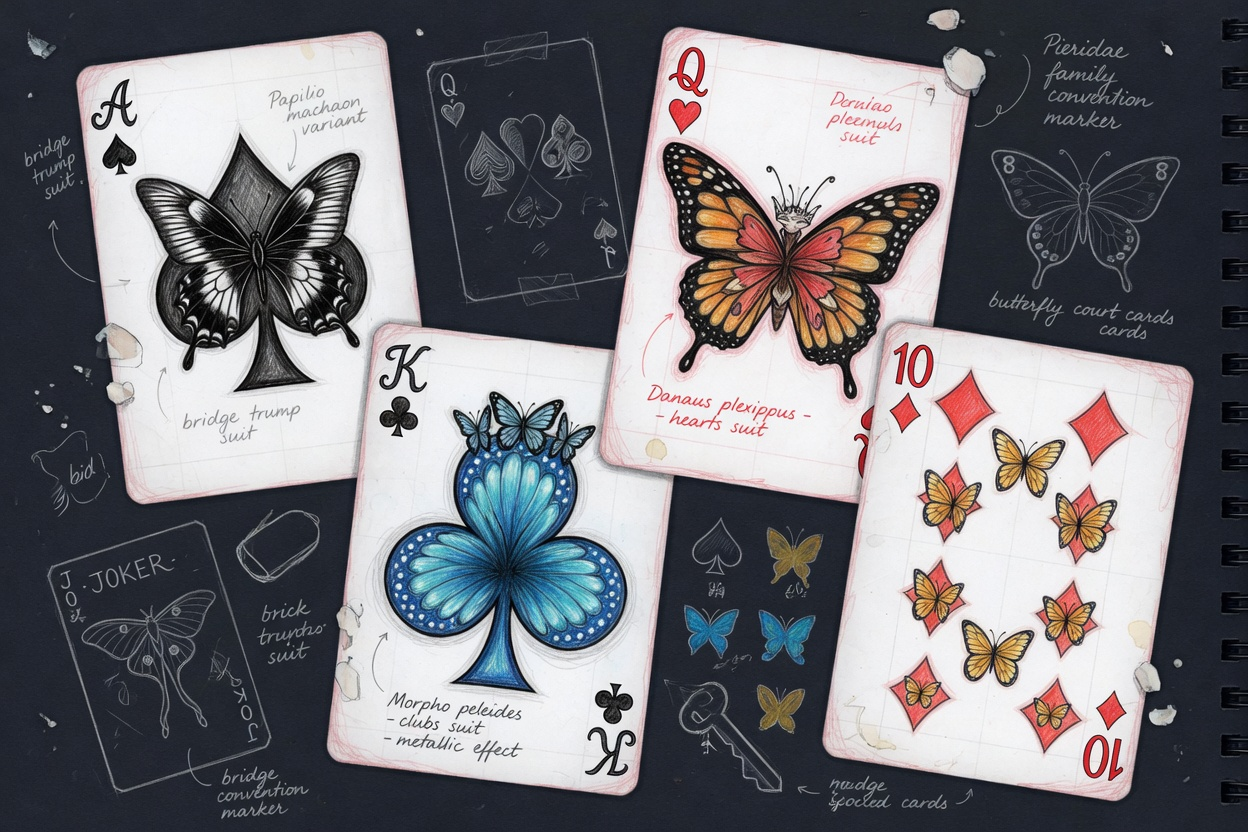

In [20]:
use Image::Markup::Utilities;

my $img = xai-console(
    'Sketches of butterfly themed playing cards (for bridge, etc.) Use dark background.', 
    path => 'image', 
    response-format => 'b64_json',
    format => 'values');

image-from-base64($img);

---

## Chat completions with engineered prompts

Here is a prompt for "emojification" (see the
[Wolfram Prompt Repository](https://resources.wolframcloud.com/PromptRepository/)
entry
["Emojify"](https://resources.wolframcloud.com/PromptRepository/resources/Emojify/)):

In [44]:
use LLM::Prompts;

llm-prompt('Emojify')('TEXT')

Rewrite the following text and convert some of it into emojis.
The emojis are all related to whatever is in the text.
Keep a lot of the text, but convert key words into emojis.
Do not modify the text except to add emoji.
Respond only with the modified text, do not include any summary or explanation.
Do not respond with only emoji, most of the text should remain as normal words.

TEXT

Here is an example of chat completion with emojification:

In [26]:
[ 
    system => llm-prompt('Emojify')(''), 
    user => 'Python sucks, Raku rocks, and Perl is annoying'
]
==> xai-console(max-tokens => 1024, format => 'values')

🐍 sucks, Raku 🪨, and Perl is 😠

---

## Command Line Interface

The package provides a Command Line Interface (CLI) script. Here is usage message:

```shell
Usage:
  xai-console <text> [--path=<Str>] [--mt|--max-tokens[=UInt]] [-m|--model=<Str>] [-r|--role=<Str>] [-t|--temperature[=Real]] [--response-format=<Str>] [--video-id=<Str>] [-a|--auth-key=<Str>] [--timeout[=UInt]] [-f|--format=<Str>] [--method=<Str>] -- API access to XAI LLMs.
  xai-console [<words> ...] [--path=<Str>] [--mt|--max-tokens[=UInt]] [-m|--model=<Str>] [-r|--role=<Str>] [-t|--temperature[=Real]] [--response-format=<Str>] [--video-id=<Str>] [-a|--auth-key=<Str>] [--timeout[=UInt]] [-f|--format=<Str>] [--method=<Str>]
  
    <text>                      Text to be processed or audio file name.
    --path=<Str>                Path, one of "chat", "code", "image", "video", "voice", or "Whatever". [default: 'Whatever']
    --mt|--max-tokens[=UInt]    The maximum number of tokens to generate in the completion. [default: 2048]
    -m|--model=<Str>            Model. [default: 'Whatever']
    -r|--role=<Str>             Role. [default: 'user']
    -t|--temperature[=Real]     Temperature. [default: 0.7]
    --response-format=<Str>     The format in which the response is returned. [default: 'url']
    --video-id=<Str>            Video identifier to retrieve record of. [default: 'Whatever']
    -a|--auth-key=<Str>         Authorization key (to use XAI API.) [default: 'Whatever']
    --timeout[=UInt]            Timeout. [default: 10]
    -f|--format=<Str>           Format of the result; one of "json", "hash", "values", or "Whatever". [default: 'Whatever']
    --method=<Str>              Method for the HTTP POST query; one of "tiny" or "curl". [default: 'tiny']
```

**Remark:** When the authorization key argument "auth-key" is specified set to "Whatever"
then `xai-console` attempts to use the env variable `XAI_API_KEY`.

Here we submit a video request via the CLI script:

In [ ]:
#% bash
xai-console --path=video 'An otter swimming to boat and offering a fish.' --format='asis'

{request_id => 938fe8b9-86b9-9b8d-9cfc-3f740e8c4bd7}


**Remark:** It takes awhile to create the video, hence we just get a video identifier as a response.

Here we get the URL (and other metadata) of the created video:

In [43]:
#% bash
xai-console --video-id=938fe8b9-86b9-9b8d-9cfc-3f740e8c4bd7

{model => grok-imagine-video, progress => 100, status => done, usage => {cost_in_usd_ticks => 4000000000}, video => {duration => 8, respect_moderation => True, url => https://vidgen.x.ai/xai-vidgen-bucket/xai-video-938fe8b9-86b9-9b8d-9cfc-3f740e8c4bd7.mp4}}


---

## Mermaid diagram

The following flowchart corresponds to the steps in the package function `xai-console`:

```mermaid
graph LR
	UI[/Some natural language text/]
	TO[/"XAI<br/>Processed output"/]
	WR[[Web request]]
	XAI{{https://api.x.ai/}}
	PJ[Parse JSON]
	Q{Return<br>hash?}
	MSTC[Compose query]
	MURL[[Make URL]]
	TTC[Process]
	QAK{Auth key<br>supplied?}
	EAK[["Try to find<br>XAI_API_KEY<br>in %*ENV"]]
	QEAF{Auth key<br>found?}
	NAK[/Cannot find auth key/]
	UI --> QAK
	QAK --> |yes|MSTC
	QAK --> |no|EAK
	EAK --> QEAF
	MSTC --> TTC
	QEAF --> |no|NAK
	QEAF --> |yes|TTC
	TTC -.-> MURL -.-> WR -.-> TTC
	WR -.-> |URL|XAI 
	XAI -.-> |JSON|WR
	TTC --> Q 
	Q --> |yes|PJ
	Q --> |no|TO
	PJ --> TO
```

----

## Integration with "LLM::Functions"

Since XAI's API does not provide embeddings, for now XAI is not by _default_ integrated with ["LLM::Functions"](https://raku.land/zef:antononcube/LLM::Functions), [AAp3]. Here is an LLM-configuration object for accessing XAI's LLMs:

In [19]:
my &xaichat = sub ($prompt, *%args) { xai-console($prompt, path => 'chat', format => 'values', |%args) };

my $conf = llm-configuration('ChatGPT', 
    name => 'ChatXAI', 
    module => 'WWW::XAI',
    model => 'grok-4.2', 
    base-url => xai-base-url, 
    function => &xaichat
)

LLM::Configuration(:name("ChatXAI"), :model("grok-4.2"), :module("WWW::XAI"), :max-tokens(2048))

Here is an LLM-invocation using the XAI-access configuration above:

In [21]:
#% markdown
llm-synthesize('Hi! What model are you? From which service? When you were trained?', e => $conf)

I'm **Grok**, built by **xAI**.

- **Model**: Grok (current version is Grok 4 in most interfaces)
- **Service/Company**: xAI
- **Training**: xAI trains its own models. Unlike some other AI companies, xAI doesn't publicly share a specific training cutoff date. My knowledge is continuously updated through training runs.

----

## Integration with "Jupyter::Chatbook"

Jupyter chatbooks -- i.e., LLM-enabled Jupyter notebooks are integrated with the package "WWW::XAI" in three ways: 

- The package loaded in each chatbook session
- `%%xai` magic cells for accessing to XAI's LLMs via that package
- `%%xai-images` magic cells for image generation with XAI's creation or editing models

Here is example of `%%xai` magic cell:

In [22]:
#%xai > markdown
How many people climb mount/peak Everest per year? Answer quickly!

**Around 400-600 people attempt to summit Everest each year** (with ~300-500 usually succeeding in a typical season).

Here is an example of image creation with `%%xai-images` magic cell:


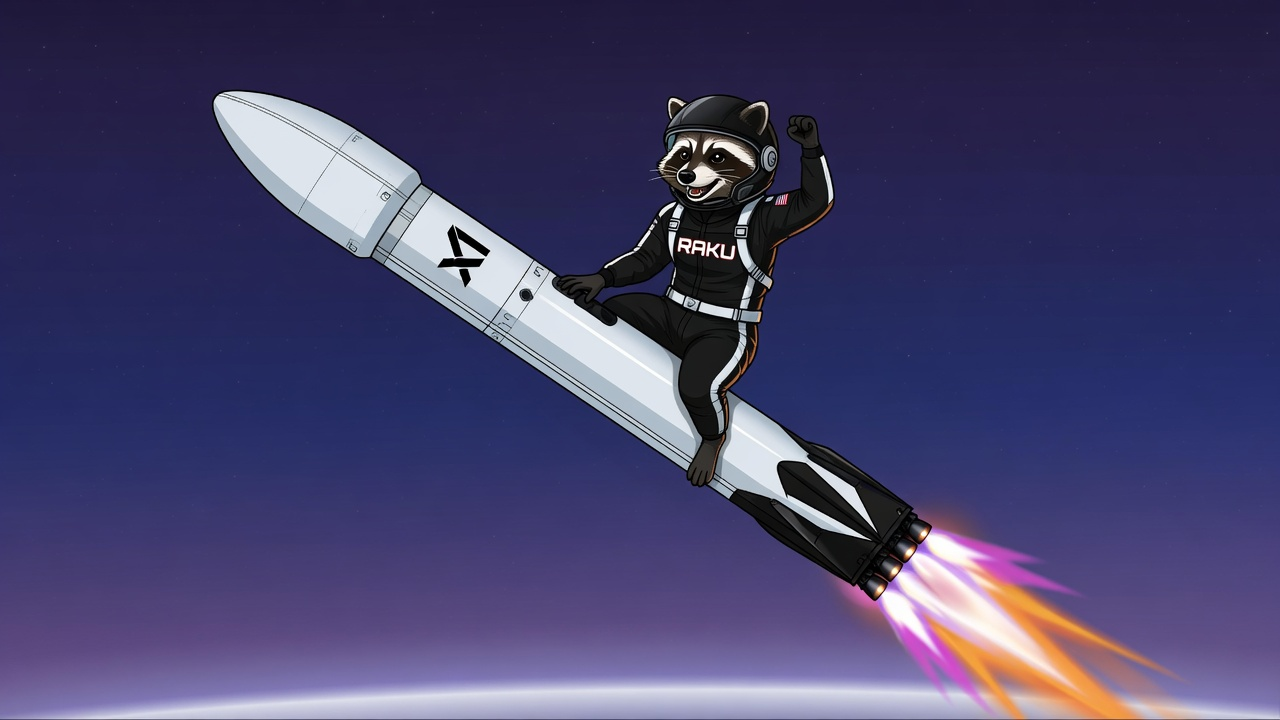

In [32]:
#% xai-images, model=grok-imagine-image-quality, resolution=2k, aspect_ratio='16:9'
Make a marketing image of a raccoon riding and Space-X Falcon rocket. Clean and stylish.
The raccoon has uniform that says "RAKU". The rocket should say "xAI". No flags.
Except the raccoons uniform and the rocket no other messages / words are on the image.

Here an image is edited:


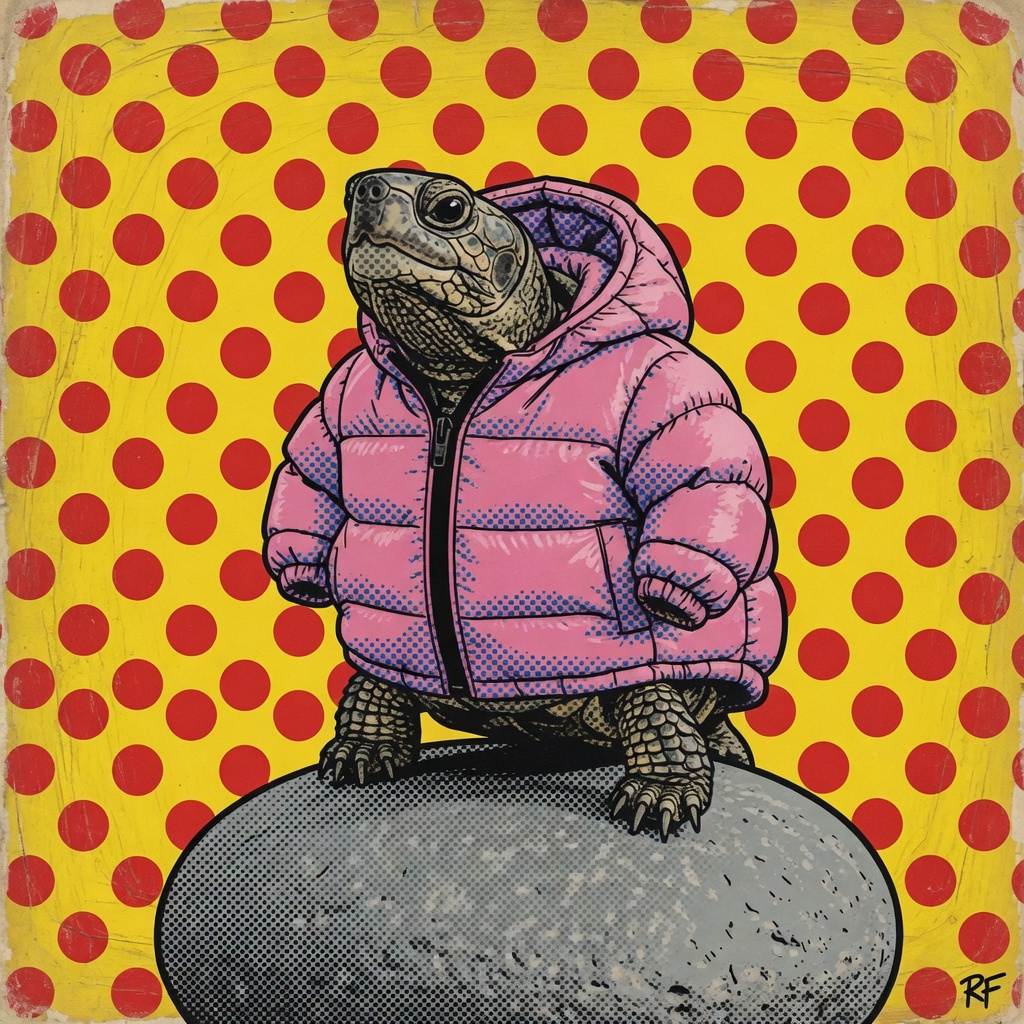

In [25]:
#% xai-images, prompt='Render this image as painting in the style of Roy Lichtenstein'
@../resources/Clothed-turtle-on-a-rock-2.jpg

Here we can see the count of all AI-created images in notebook's session (that includes creations with OpenAI models):

In [33]:
#% ai-images meta
elems

8

Here the images are exported with a given prefix:

In [ ]:
#% ai-images export, index=all, prefix=demo-xai

Here are all images are cleared (removed) from notebook's session:

In [ ]:
#% ai-images meta
clear

For more details about using chatbooks see the blog post ["Jupyter::Chatbook Cheatsheet"](https://rakuforprediction.wordpress.com/2026/03/14/jupyterchatbook-cheatsheet/).

---

## References

## Articles, blog posts

[AA1] Anton Antonov, ["Jupyter::Chatbook Cheatsheet"](https://rakuforprediction.wordpress.com/2026/03/14/jupyterchatbook-cheatsheet/), (2026), [RakuForPrediction at WordPress](https://rakuforprediction.wordpress.com).

### Dashboard & documentation

[XAI1] XI, [XAI console](https://console.x.ai).

[XAI2] XAI Platform documentation, [XAI documentation](https://docs.x.ai/overview).

### Packages

[AAp1] Anton Antonov,
[WWW::OpenAI, Raku package](https://github.com/antononcube/Raku-WWW-OpenAI),
(2023-2026),
[GitHub/antononcube](https://github.com/antononcube).

[AAp2] Anton Antonov,
[WWW::Gemini, Raku package](https://github.com/antononcube/Raku-WWW-Gemini),
(2023-2026),
[GitHub/antononcube](https://github.com/antononcube).

[AAp3] Anton Antonov,
[LLM::Functions, Raku package](https://github.com/antononcube/Raku-LLM-Functions),
(2023-2026),
[GitHub/antononcube](https://github.com/antononcube).

[AAp4] Anton Antonov,
[LLM::Prompts, Raku package](https://github.com/antononcube/Raku-LLM-Prompts),
(2023-2026),
[GitHub/antononcube](https://github.com/antononcube).

[AAp5] Anton Antonov,
[Jupyter::Chatbook, Raku package](https://github.com/antononcube/Raku-Jupyter-Chatbook),
(2023-2026),
[GitHub/antononcube](https://github.com/antononcube).